In [ ]:
import numpy
import itertools
import math
import gsd.hoomd
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display


#Grabbing helper scripts
import md_Helpers.Create_Lattices as cl
import md_Helpers.Simulation_Helpers as sh
import md_Helpers.Logging_Helpers as lh
import md_Helpers.viz_helpers as vh
from md_Helpers.Project_Paths import THERMALIZED_STATES_ROOT


import importlib
importlib.reload(cl)
importlib.reload(sh)
importlib.reload(lh)
importlib.reload(vh)

In [ ]:
BoxLength = 50
rho = .4

In [ ]:
lattice_path = cl.get_lattice_path(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="fcc",
)

frame = cl.make_lattice_frame(
    BoxLength=BoxLength,
    rho=rho,
    lattice_type="fcc",
)

In [ ]:
sim = sh.make_simulation(
    frame,
    starting_state_path=lattice_path,
    kT = .4,
    seed=np.random.randint(0, 100),
)

In [ ]:
sim = sh.thermalize_and_randomize(sim, nsteps=10_000_000, log = True, log_period = 10000)

display(vh.render(sim.state.get_snapshot()))

paths = sim.logged_paths
log_data = lh.read_hdf5_log(paths["log_path"])
log_data["metadata"]["attrs"]["seed"]

Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_10000000_log.hdf5


In [6]:
for i in range(10):
    sim = sh.make_simulation(frame, starting_state_path=lattice_path,kT = .4)
    nsteps = 500 * (i + 1)
    sh.thermalize_and_randomize(sim, nsteps=nsteps, phase_name="randomization", log = True)
    print(f"Finished nsteps = {nsteps}")

print("done")

Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f2346aeee90>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_500_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_500.gsd
Finished nsteps = 500
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f2346aedbd0>
Started HDF5 logger
Log file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000_log.hdf5
Stopped HDF5 logger
Wrote HDF5 metadata
Saved final state
GSD file: /exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000.gsd
Finished nsteps = 1000
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f282b3c75c0>
S

In [7]:
paths = sim.logged_paths
log_data = lh.read_hdf5_log(paths["log_path"])

log_data.keys()

dict_keys(['hoomd-data', 'metadata'])

In [29]:
log_data["metadata"]["attrs"]

{'Lx': 50.0,
 'Ly': 50.0,
 'Lz': 50.0,
 'N': 48668,
 'actual_rho': 0.389344,
 'dt': 0.005,
 'epsilon_LJ': 1.0,
 'final_timestep': 1000000,
 'kT': 0.4,
 'lj_mode': 'xplor',
 'log_period': 1000,
 'nsteps': 1000000,
 'phase_name': 'randomization',
 'r_cut_LJ': 2.5,
 'r_on_LJ': 2.0,
 'seed': 1,
 'sigma_LJ': 1.0,
 'starting_state_path': '',
 'target_rho': 0.389344,
 'volume': 125000.0}

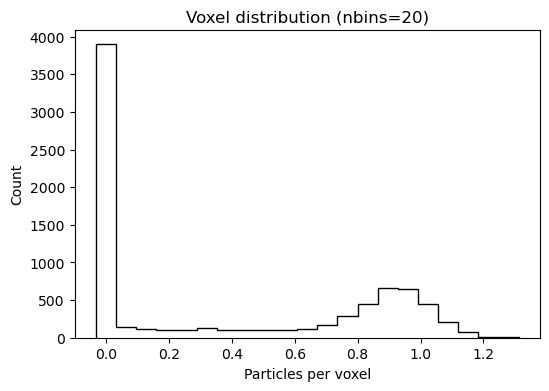

In [9]:
vh.plot_voxel_histogram(sim, nbins = 20);

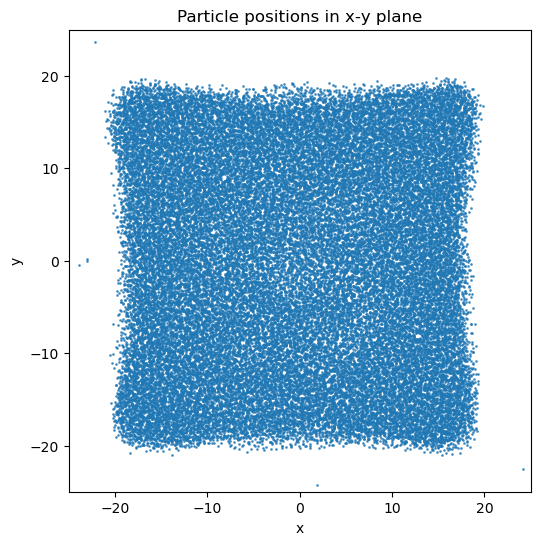

In [10]:
vh.plot_xy_particles(sim)

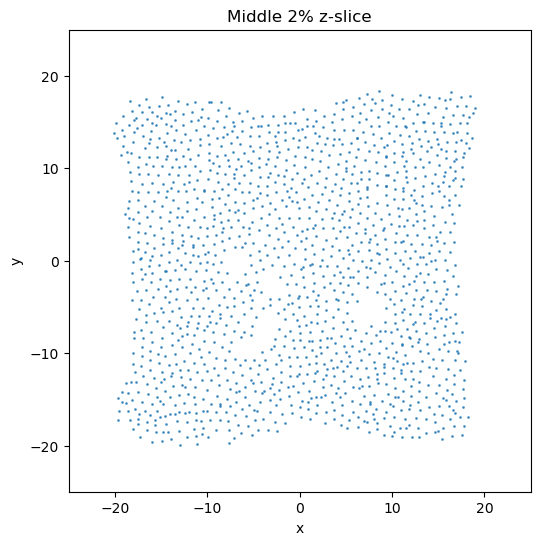

In [11]:
vh.plot_xy_slice(sim, fraction=0.025)

In [12]:
#how long does it take to phase separate
#    rho around crit rho = .4
#    kT sig smaller than crit temp


Voxel histogram for nsteps = 500
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_500.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6b1b033350>


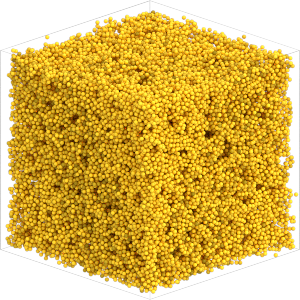

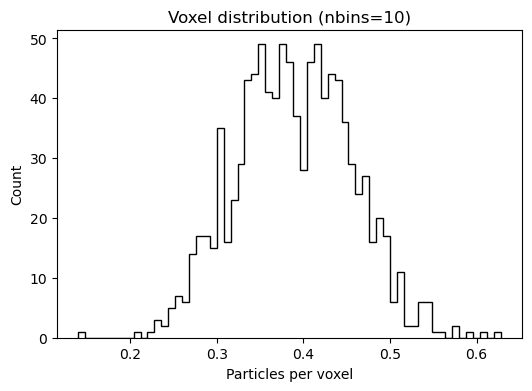


Voxel histogram for nsteps = 1,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1000.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a8824a650>


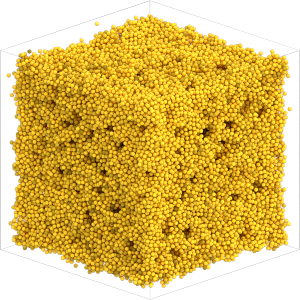

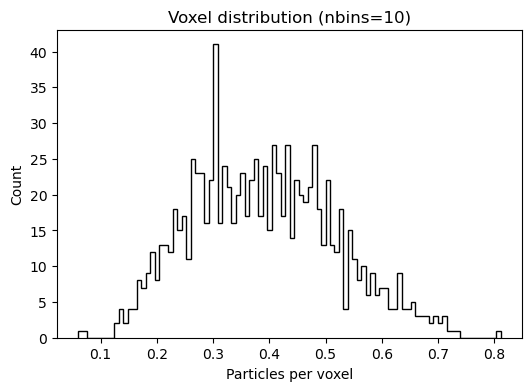


Voxel histogram for nsteps = 1,500
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_1500.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a8824bd50>


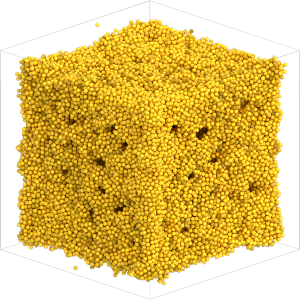

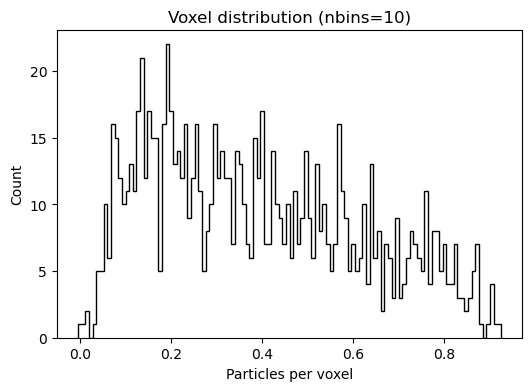


Voxel histogram for nsteps = 2,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_2000.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a88267020>


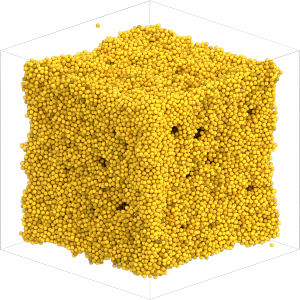

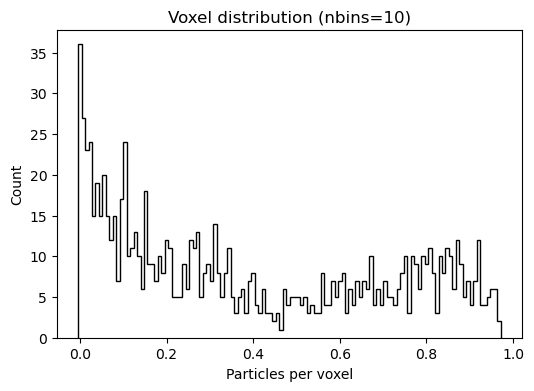


Voxel histogram for nsteps = 2,500
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_2500.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a88267e30>


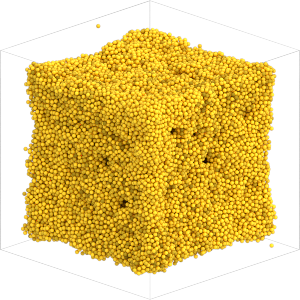

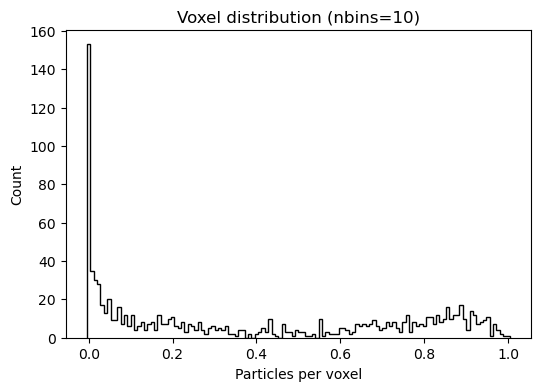


Voxel histogram for nsteps = 3,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_3000.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a63e766d0>


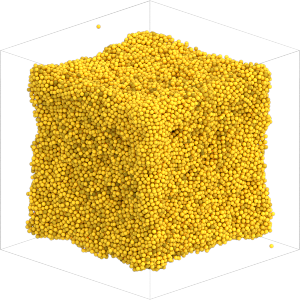

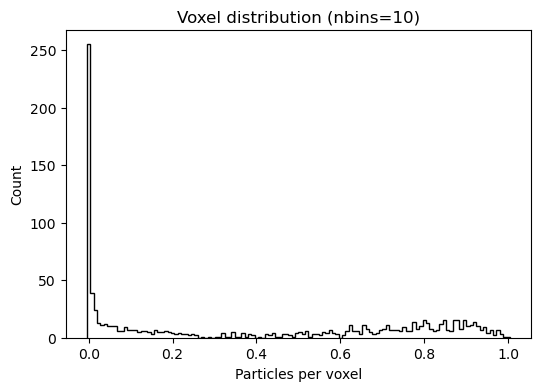


Voxel histogram for nsteps = 3,500
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_3500.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a63ceb690>


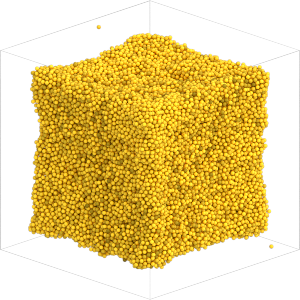

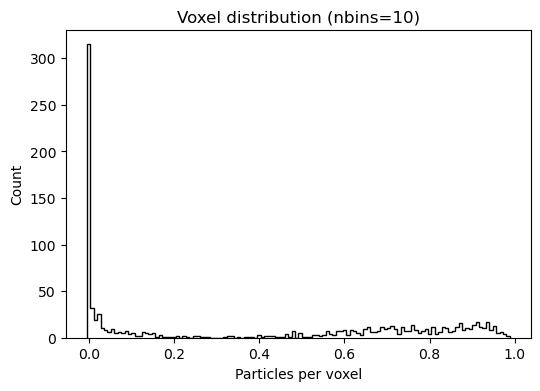


Voxel histogram for nsteps = 4,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_4000.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a63f0b2b0>


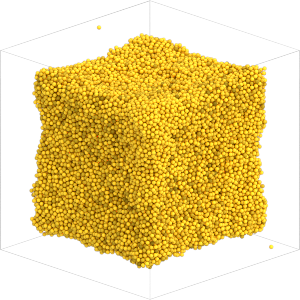

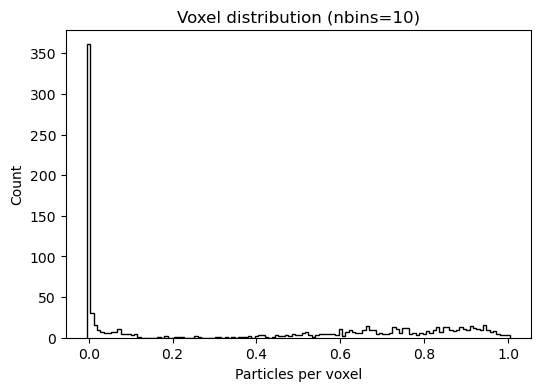


Voxel histogram for nsteps = 4,500
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_4500.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a63e51c10>


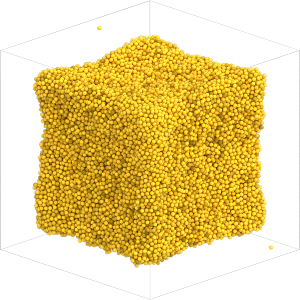

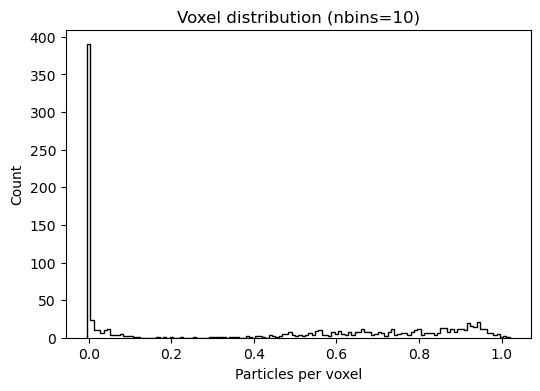


Voxel histogram for nsteps = 5,000
/exp/e961/data/MDsims-data/pnichols/Thermalized_States/BoxLength_50.0/rho_0.39/kT_0.40/randomization_nsteps_5000.gsd
Starting Simulation --------------- Final device: <hoomd.device.GPU object at 0x7f6a63e519d0>


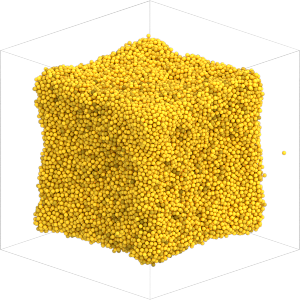

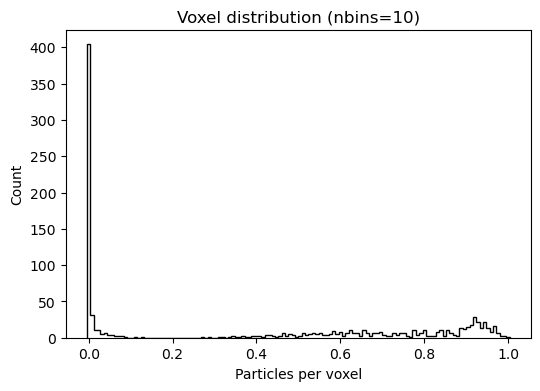

In [27]:
# ============================================================
# Plot voxel histograms for completed nsteps sweep
# ============================================================

from pathlib import Path
import gsd.hoomd


BoxLength = 50.0
rho = 0.39
kT = 0.40

folder = (
    THERMALIZED_STATES_ROOT
    / f"BoxLength_{BoxLength:.1f}"
    / f"rho_{rho:.2f}"
    / f"kT_{kT:.2f}"
)

nsteps_list = [500 * i for i in range(1, 11)]

from IPython.display import display

for nsteps in nsteps_list:
    state_path = folder / f"randomization_nsteps_{nsteps}.gsd"

    print("\n" + "=" * 80)
    print(f"Voxel histogram for nsteps = {nsteps:,}")
    print(state_path)

    with gsd.hoomd.open(name=str(state_path), mode="r") as f:
        frame = f[0]

    sim = sh.make_simulation(frame, kT=kT)
    sim.run(0)

    display(vh.render(frame))

    vh.plot_voxel_histogram(
        sim,
        nbins=10,
        use_density=False,
    )